In [1]:
!pip install -U pysr

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 4.0 MB/s eta 0:00:00


In [2]:
import pysr

[juliapkg] Found dependencies: /usr/local/lib/python3.11/dist-packages/juliapkg/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.11/dist-packages/pysr/juliapkg.json
[juliapkg] Found dependencies: /usr/local/lib/python3.11/dist-packages/juliacall/juliapkg.json
[juliapkg] Locating Julia =1.10.0, ^1.10.3
[juliapkg] Using Julia 1.10.9 at /usr/local/bin/julia
[juliapkg] Using Julia project at /root/.julia/environments/pyjuliapkg
[juliapkg] Writing Project.toml:
             [deps]
             SymbolicRegression = "8254be44-1295-4e6a-a16d-46603ac705cb"
             Serialization = "9e88b42a-f829-5b0c-bbe9-9e923198166b"
             PythonCall = "6099a3de-0909-46bc-b1f4-468b9a2dfc0d"
             OpenSSL_jll = "458c3c95-2e84-50aa-8efc-19380b2a3a95"
             [compat]
             SymbolicRegression = "~1.11"
             Serialization = "^1"
             PythonCall = "=0.9.25"
             OpenSSL_jll = "~3.0"
[juliapkg] Installing packages:
             import Pkg
    

In [3]:
import sympy
import numpy as np
from matplotlib import pyplot as plt
from pysr import PySRRegressor
from sklearn.model_selection import train_test_split

In [4]:
# Load your dataset from a CSV file
import pandas as pd
df = pd.read_csv("/content/all_data_cf_fnl.csv")  # Replace with your file path

# Split dataset into input features (X) and target variable (y)
# Assumes the last column is the target
X = df.iloc[:, 0:6].values
y = df.iloc[:, -2].values

In [6]:
print(y)

[7.94065657 8.01805758 8.0894306  8.15573214 8.21780323 8.27633798
 8.33186345 8.38473507 8.43515063 8.48318338 8.52883013 8.57206639
 8.61289851 8.65140397 8.68775462 8.72222246 8.75517115 8.78703873
 8.81831632 8.88120703 8.84367002 8.75840993 8.67261575 8.58589512
 8.49799444 8.40876317 8.31811945 8.2260203  8.13243726 8.03733594
 7.84229137 7.74205587 7.63965501 7.5346521  7.42645705 7.31435531
 7.19759406 7.0755238  6.94776863 6.81437989 7.94054596 7.94018228
 7.93981184 7.93977998 7.94012334 7.94038469 7.94089154 7.94103469
 7.94037616 7.93858024 7.93934872 7.93970004 7.94055248 7.94106466
 7.94090178 7.9403286  7.93999032 7.9403375  7.9409618  7.9402017
 7.93120145 7.92084177 7.90950921 7.89713322 7.88363975 7.86894888
 7.85297115 7.83560218 7.81671506 7.7961502  7.7737022  7.7491037
 7.72200659 7.69196159 7.65839897 7.62061468 7.57776922 7.52890919
 7.47302392 7.40914862 7.00825034 7.1495978  7.28276528 7.4080477
 7.5259965  7.63735356 7.74298009 7.84378497 8.03440218 8.1256988

In [ ]:
#print(X)

In [17]:
#import numpy as np
#from pysr import PySRRegressor

# Generate sample data
# Example: y = 3*x**2 - 2*x + 5
np.random.seed(0)
#X = np.random.uniform(-10, 10, (100, 1))
#y = 3 * X[:, 0]**2 - 2 * X[:, 0] + 5 + np.random.normal(0, 5, size=100)

# Define and fit the model
model = PySRRegressor(
    niterations=100,
    binary_operators=["+", "-", "*"],  # allow only polynomial operations
    unary_operators=["square", "cube", "exp", "sin", "cos"],  # optional: include power terms
    extra_sympy_mappings={
        "square": lambda x: x**2,
        "cube": lambda x: x**3
    },
    loss="loss(x, y) = (x - y)^2",
    maxsize=20,
    model_selection="best",  # choose simplest best model
    #verbose=True,
)

# Fit the model
model.fit(X, y)

# Print discovered equations
print(model)

/usr/local/lib/python3.11/dist-packages/pysr/sr.py:1036: FutureWarning: `loss` has been renamed to `elementwise_loss` in PySRRegressor. Please use that instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 9.920e+04
Progress: 541 / 3100 total iterations (17.452%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.262e-01  0.000e+00  y = 8.0275
2           1.706e-01  2.821e-01  y = cube(x₅)
4           1.463e-01  7.684e-02  y = x₀ + exp(x₅)
5           1.098e-01  2.871e-01  y = (x₅ - x₁) * 5.3397
6           8.731e-02  2.291e-01  y = exp(x₅ + (0.57812 - x₁))
7           6.452e-02  3.025e-01  y = cube(sin(x₀) + (x₅ - x₁))
8           3.137e-02  7.212e-01  y = exp(x₀ + (x₅ - x₁)) + 0.45053
10          2.186e-02  1.806e-01  y = exp(((sin(x₀) + exp(x₄)) - x₁) + x₅)
11          1.943e-02  1.180e-01  y = exp(square(x₅ - (x₁ + 0.30422))) + (x₀ * 7.2719)
12          1.455e-02  2.887e-01  y = (x₀ * 6.9802) + (((x₁ * 4.2568) - square(x₅)) * -2.332...
          

[ Info: Final population:
[ Info: Results saved to:


───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           2.262e-01  0.000e+00  y = 8.0275
2           1.706e-01  2.821e-01  y = cube(x₅)
4           1.463e-01  7.684e-02  y = x₀ + exp(x₅)
5           1.098e-01  2.871e-01  y = (x₅ - x₁) * 5.3397
6           8.671e-02  2.361e-01  y = square((x₅ - x₁) * 1.8826)
7           6.452e-02  2.956e-01  y = cube(sin(x₀) + (x₅ - x₁))
8           3.137e-02  7.212e-01  y = exp(x₀ + (x₅ - x₁)) + 0.45053
9           1.807e-02  5.513e-01  y = exp(x₅ + (sin(x₀ - -0.097552) - x₁))
10          1.705e-02  5.823e-02  y = exp((0.22121 - x₁) + (x₅ - (x₀ * -0.68688)))
11          7.937e-03  7.646e-01  y = x₄ + exp((sin(x₀ + 0.51781) + x₅) - x₁)
12          7.219e-03  9.487e-02  y = exp((sin(exp(x₀ + -0.48334)) - x₁) + x₅) + x₄
13          5.542e-03  2.644e-01  y = (x₄ + exp(x₅ + (sin(x₀ + 0.38703) - x₁))) - -0.75824
14          3.672e-03  4.114e-01  y = ((x₀ * 5.60

In [18]:
model.sympy()

x0*5.600921 + x4*x1*3.6837194 - (-2.4758239)*x5**2

In [19]:
import numpy as np
def symbolic_function(Z):
    term1 = Z[0]*5.600921
    term2 = Z[1]*Z[4]*3.6837194
    term3 = (Z[5]**2)*(-2.4758239)
    return term1 + term2 - term3


In [20]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/all_data_cf_fnl.csv")  # Replace with your actual path

# Extract input features (first 6 columns)
X = df.iloc[:, 0:6].values
y = df.iloc[:, -2].values

# Define your custom function
# custom_function(Z):
#    return (Z[0]*(-4.3583193)
#            + (Z[4] - 0.93447506)**2
#            + (Z[1] - Z[5] + 0.24600449)**3
#            - 3.8498328)

# Compute results and store them
results = []
for row in X:
    results.append(symbolic_function(row))

# Create a new DataFrame to save
output_df = pd.DataFrame({
    'Symbolic_Result': results
})


In [21]:
df2 = pd.read_csv("/content/ValidationResults_final.csv")  # Replace with your actual path
X_val = df2.iloc[:, 0:6].values
y_val = df2.iloc[:, 8].values

In [22]:
y_val

array([7.94115509, 8.08481324, 8.43621868, 8.88293474, 7.19530411,
       7.07371473, 6.81594628, 7.94014643, 7.93945876, 7.89607567,
       7.88315221, 7.83691353, 7.43452151, 7.63804122, 8.63807687])

In [23]:
# Compute results and store them
results_val = []
for row in X_val:
    results_val.append(symbolic_function(row))

# Create a new DataFrame to save
output_df = pd.DataFrame({
    'Symbolic_Result': results_val
})


In [24]:
results_val

[np.float64(7.9149208799999995),
 np.float64(8.026939299999999),
 np.float64(8.362994559999999),
 np.float64(9.03510508),
 np.float64(7.244483949199999),
 np.float64(7.1487072448),
 np.float64(6.957153835999999),
 np.float64(7.9149208799999995),
 np.float64(7.9149208799999995),
 np.float64(7.841246491999999),
 np.float64(7.822827895),
 np.float64(7.767572103999999),
 np.float64(7.54654894),
 np.float64(7.620050253509999),
 np.float64(8.72302980096)]

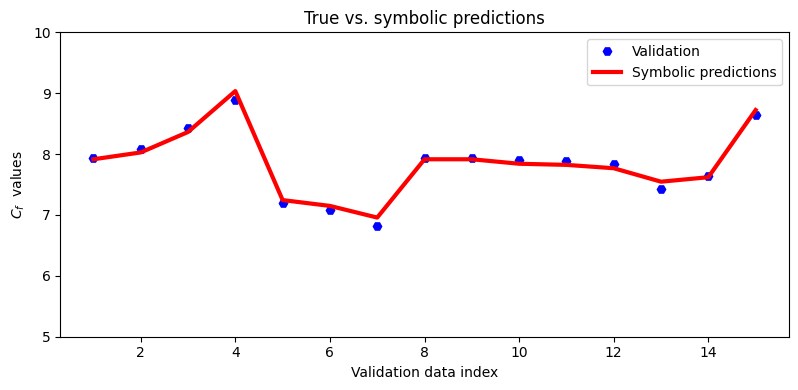

In [34]:
import numpy as np
import matplotlib.pyplot as plt

# Point-wise error
#errors = y_true - y_pred
# Plotting

# Create shifted index starting from 1
index = np.arange(1, len(y_val)+1)
plt.figure(figsize=(8, 4))
plt.plot(index, y_val, marker='H', linestyle='None', color='blue', label='Validation')
plt.plot(index, results_val, marker='None', linestyle='-', color='red', linewidth=3, label='Symbolic predictions')
plt.axhline(0, color='gray', linestyle='None')
plt.xlabel('Validation data index')
plt.ylabel('$C_f$  values')
#plt.ylabel('Error (True - Predicted)')
plt.title('True vs. symbolic predictions')
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.ylim([5, 10])
plt.savefig("True_vs_symbolic_C_f_U_1.eps", format="eps")
plt.show()

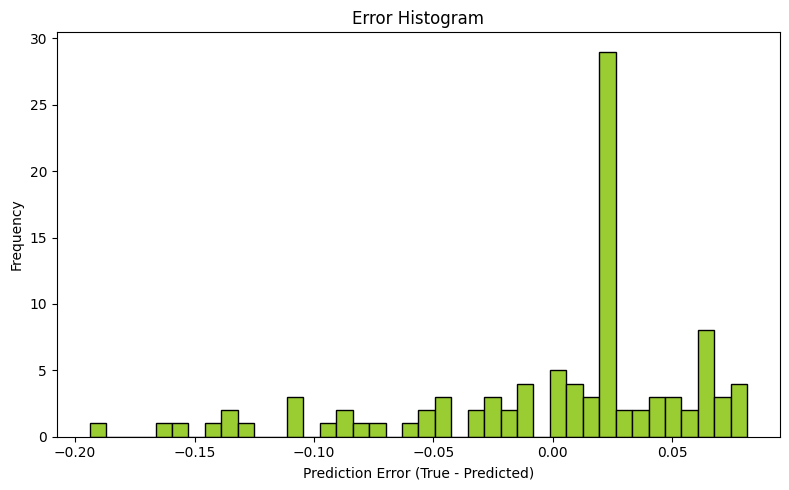

In [26]:
import numpy as np
import matplotlib.pyplot as plt
# Sample data
y_true = y
y_pred = results

errors=y_true-y_pred
# Plotting
# Plot error histogram
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=40, edgecolor='black', color='yellowgreen')
plt.xlabel('Prediction Error (True - Predicted)')
plt.ylabel('Frequency')
plt.title('Error Histogram')
#plt.grid(True)
plt.tight_layout()
plt.savefig("Error_Histogram.eps", format="eps")
plt.show()

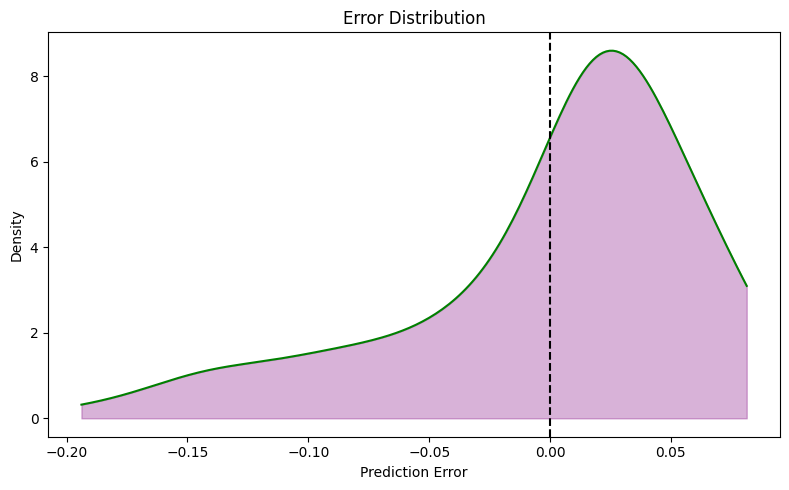

In [27]:
from scipy.stats import gaussian_kde

# KDE for error distribution
density = gaussian_kde(errors)
xs = np.linspace(min(errors), max(errors), 200)

plt.figure(figsize=(8, 5))
plt.plot(xs, density(xs), color='green')
plt.fill_between(xs, density(xs), alpha=0.3, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title('Error Distribution') #  (KDE= Kernel Density Estimation)
plt.xlabel('Prediction Error')
plt.ylabel('Density')
#plt.grid(True)
plt.tight_layout()

# Save the figure in EPS format
plt.savefig("error_distribution.eps", format="eps")
plt.show()


In [ ]:
def custom_function(Z):
    return (Z[0]*(-4.3583193)
            + (Z[4] - 0.93447506)**2
            + (Z[1] - Z[5] + 0.24600449)**3
            - 3.8498328)

Z1 = [0.5, 0.5, 2, 1, -2.6, 2]
Z2 = [0.51, 0.5, 2, 1, -2.6, 2]
Z3 = [0.7, 0.5, 2, 1, -2.6, 2]
print(custom_function(Z3))
## Example: generate 10 different x vectors and store function values
#function_values = []
#for i in range(10):
#    # Example x vector of 6 elements; change this logic as needed
#    Z = [i + j for j in range(6)]  # e.g., [i, i+1, i+2, ..., i+5]
#
#    f_val = custom_function(Z)
#    function_values.append(f_val)

# Print results
#for i, val in enumerate(function_values):
#    print(f"f(x) at index {i}: {val}")


In [ ]:
Z1 = [0.5, 0.5, 2, 1, -2.6, 2]
Z2 = [0.51, 0.5, 2, 1, -2.6, 2]
Z3 = [0.7, 0.5, 2, 1, -2.6, 2]
print(custom_function(Z3))

3.6199437574766837


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/all_data_cf_fnl.csv")  # Replace with your actual path

# Extract input features (first 6 columns)
X = df.iloc[:, 0:6].values
y = df.iloc[:, -1].values
# Define your custom function
def custom_function(Z):
    return (Z[0]*(-4.3583193)
            + (Z[4] - 0.93447506)**2
            + (Z[1] - Z[5] + 0.24600449)**3
            - 3.8498328)

# Compute results and store them
results = []
for row in X:
    results.append(custom_function(row))

# Create a new DataFrame to save
output_df = pd.DataFrame({
    'Symbolic_Result': results
})

# Save to CSV
output_df.to_csv("custom_function_output.csv", index=False)
print("Results saved to custom_function_output.csv")


Results saved to custom_function_output.csv


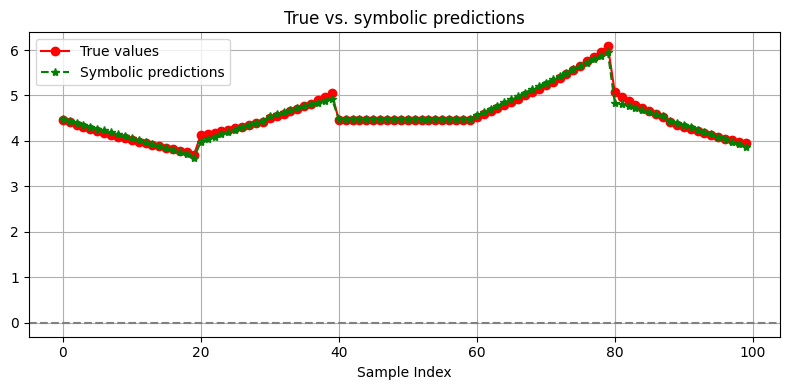

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
y_true = y
y_pred = results
# Point-wise error
#errors = y_true - y_pred
# Plotting
plt.figure(figsize=(8, 4))
plt.plot(y_true, marker='o', linestyle='-', color='red', label='True values')
plt.plot(y_pred, marker='*', linestyle='--', color='green', label='Symbolic predictions')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Sample Index')
#plt.ylabel('Error (True - Predicted)')
plt.title('True vs. symbolic predictions')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# MSE for True - Symbolic_predicted
#y-results
import numpy as np

mse = np.mean((y-results) ** 2)
print("MSE:", mse)

MSE: 0.0032542970245511694


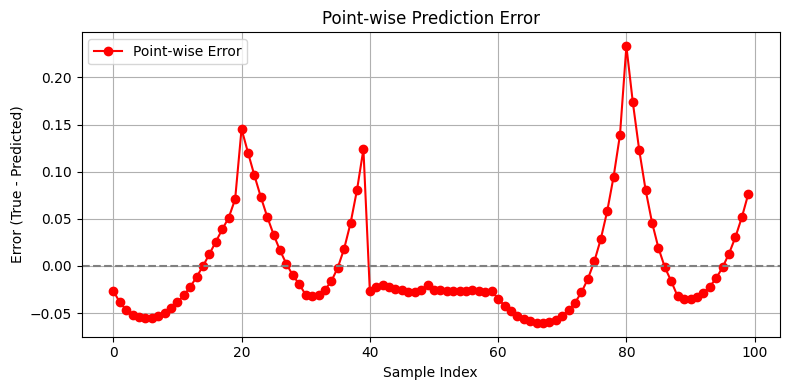

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data
y_true = y
y_pred = results
# Point-wise error
errors = y_true - y_pred
# Plotting
plt.figure(figsize=(8, 4))
plt.plot(errors, marker='o', linestyle='-', color='red', label='Point-wise Error')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Sample Index')
plt.ylabel('Error (True - Predicted)')
plt.title('Point-wise Prediction Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

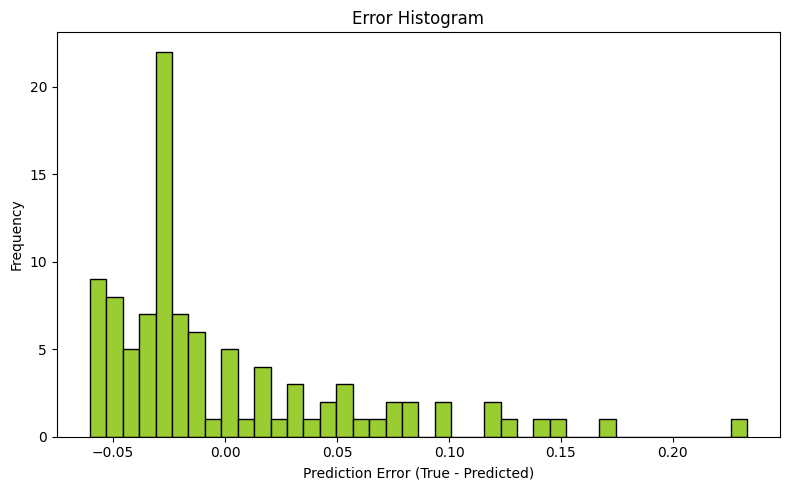

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Plot error histogram
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=40, edgecolor='black', color='yellowgreen')
plt.xlabel('Prediction Error (True - Predicted)')
plt.ylabel('Frequency')
plt.title('Error Histogram')
#plt.grid(True)
plt.tight_layout()
plt.show()


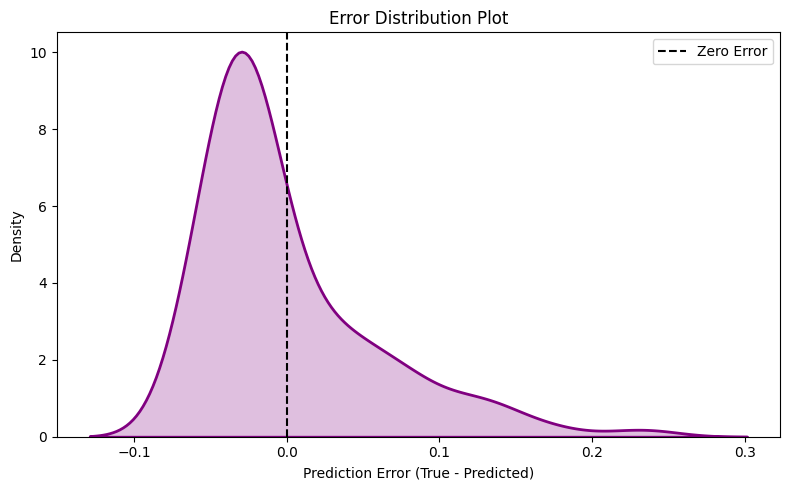

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Compute errors
#errors = y_true - y_pred

# Plot error distribution using KDE
plt.figure(figsize=(8, 5))
sns.kdeplot(errors, fill=True, color='purple', linewidth=2)
plt.axvline(0, color='black', linestyle='--', label='Zero Error')
plt.title('Error Distribution Plot')
plt.xlabel('Prediction Error (True - Predicted)')
plt.ylabel('Density')
plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.show()


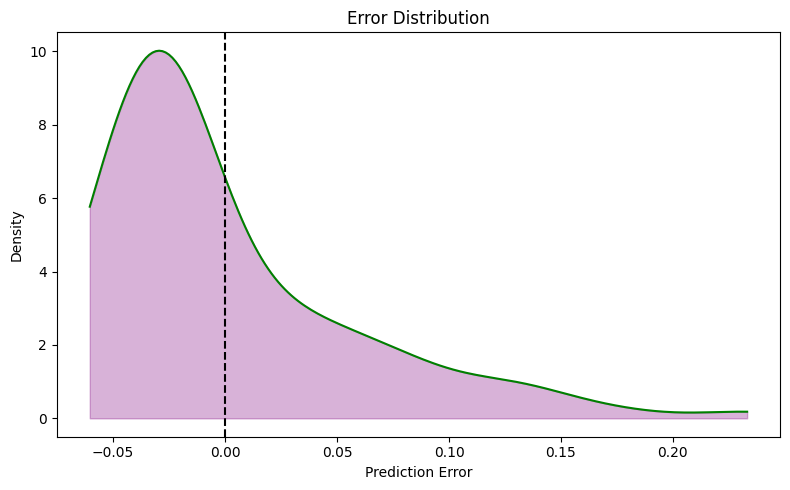

In [ ]:
from scipy.stats import gaussian_kde

# KDE for error distribution
density = gaussian_kde(errors)
xs = np.linspace(min(errors), max(errors), 200)

plt.figure(figsize=(8, 5))
plt.plot(xs, density(xs), color='green')
plt.fill_between(xs, density(xs), alpha=0.3, color='purple')
plt.axvline(0, color='black', linestyle='--')
plt.title('Error Distribution') #  (KDE= Kernel Density Estimation)
plt.xlabel('Prediction Error')
plt.ylabel('Density')
#plt.grid(True)
plt.tight_layout()

# Save the figure in EPS format
#plt.savefig("error_distribution.eps", format="eps")
plt.show()
